# Лабораторная работа №3: Фильтрация и анализ временных рядов

**Студент:** Вариант 30 (расчет: $(471882) \bmod 60 = 30$)  
**Цель работы:** Исследовать структуру временного ряда продаж, оценить взаимосвязи признаков, выявить периодичность и реализовать методы цифровой фильтрации (EMA, Калман, Савицкий-Голей, адаптивный фильтр LMS).

# 0. Инициализация

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Any
from pathlib import Path
from typing import cast


# Добавляем корень лабораторной в путь импорта для корректной загрузки src
sys.path.append(str(Path.cwd()))

from src.utils import seed_everything, load_variant_data, compute_metrics, compute_autocorrelation
from src.filters import ExponentialSmoothing, KalmanFilter1D, SavitzkyGolayFilter, LMSFilter

# Фиксация случайного состояния для воспроизводимости
seed_everything(76)

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# 1. Задача 3. Исследовательский анализ данных (EDA)

Перед применением алгоритмов фильтрации необходимо исследовать свойства исследуемого ряда:
1. Оценить диапазоны значений, средние уровни и волатильность признаков.
2. Проверить взаимосвязь объемов продаж отдельных категорий товаров с итоговой прибылью.
3. Исследовать временной ряд на наличие тренда, локальных циклов и периодичности с помощью автокорреляционной функции (ACF).

## 1.1 Загрузка данных Варианта 30


In [2]:
df = load_variant_data('sell.csv', variant=30)

print("Размерность датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

print("\nОписательные статистики:")
display(df.describe().round(2))

Размерность датасета: (50, 7)

Первые 5 строк:


,day,мыло,порошок,средство,краска,пена,прибыль
0,1,118.0,18.0,24.0,42.0,21.0,28.385
1,2,70.0,20.0,14.0,46.0,23.0,28.278
2,3,92.0,20.0,21.0,44.0,19.0,26.606
3,4,78.0,19.0,20.0,39.0,19.0,25.603
4,5,109.0,20.0,26.0,42.0,16.0,27.840



Описательные статистики:


,day,мыло,порошок,средство,краска,пена,прибыль
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,25.50,96.96,18.42,21.66,42.62,20.24,27.04
std,14.58,16.70,4.76,3.23,1.78,2.16,1.71
min,1.00,68.00,4.00,12.00,38.00,16.00,23.36
25%,13.25,84.25,16.00,20.00,42.00,19.00,25.71
50%,25.50,98.50,19.00,22.00,43.00,20.00,27.24
75%,37.75,108.75,21.00,24.00,44.00,21.75,28.09
max,50.00,123.00,29.00,30.00,46.00,26.00,31.42


## 1.2. Корреляционный анализ факторов прибыли
Оценим, продажи каких именно товаров оказывают решающее влияние на финансовый результат. Используем столбец `прибыль`. Для этого рассчитаем парные коэффициенты корреляции Пирсона и построим тепловую карту.

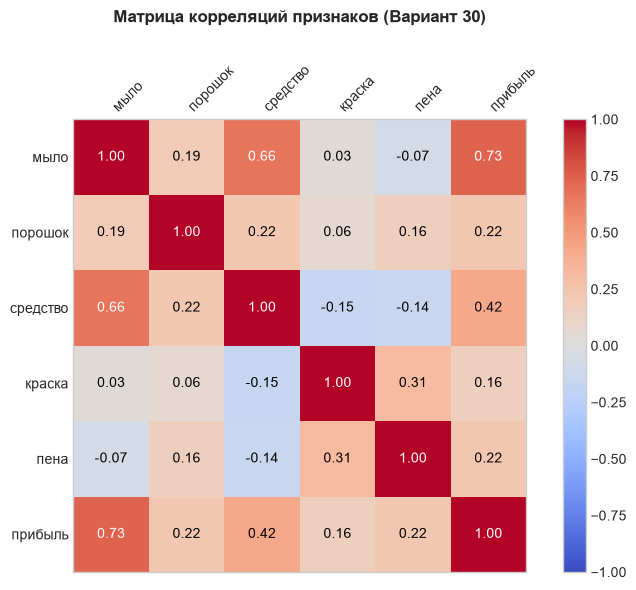

Корреляция с целевым показателем (прибыль):
прибыль     1.000
мыло        0.729
средство    0.415
порошок     0.225
пена        0.221
краска      0.158
Name: прибыль, dtype: float64


In [3]:
features = ['мыло', 'порошок', 'средство', 'краска', 'пена', 'прибыль']
corr_matrix = df[features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='left')
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        val = cast(float, corr_matrix.iloc[i, j])
        ax.text(j, i, f"{val:.2f}", 
            ha="center", va="center",
            color="white" if abs(val) > 0.5 else "black",
        )

plt.title('Матрица корреляций признаков (Вариант 30)', pad=30, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.show()

print("Корреляция с целевым показателем (прибыль):")
print(corr_matrix['прибыль'].sort_values(ascending=False).round(3))

**Факторы формирования прибыли (Корреляционный анализ):**
- Продажи товара **"мыло"** выступают ключевым драйвером финансового результата с сильной положительной связью ($r = 0.729$)
- Товар **"средство"** оказывает умеренное положительное влияние ($r = 0.415$) и тесно коррелирует с мылом ($r = 0.66$)
- Порошок ($r = 0.225$), пена ($r = 0.221$) и краска ($r = 0.158$) вносят менее значительный линейный вклад в суммарную прибыль

## 1.3. Временная динамика и анализ периодичности (ACF)
Построим графики изменения прибыли и ключевого товара во времени, а также рассчитаем выборочную автокорреляционную функцию (ACF) для выявления скрытых ритмов спроса.

### 1.3.1 Динамика прибыли и ключевого драйвера (мыло) за 50 дней

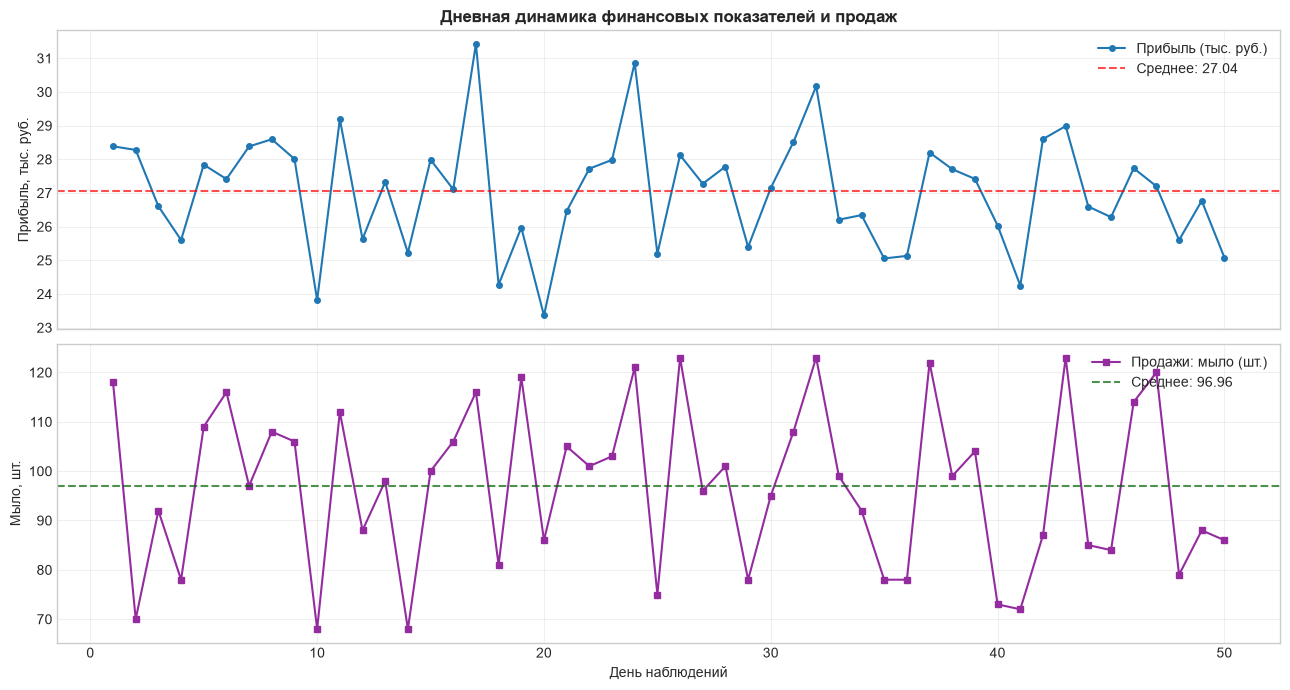

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(df['day'], df['прибыль'], color='#1f77b4', marker='o', markersize=4, linewidth=1.5, label='Прибыль (тыс. руб.)')
ax1.axhline(df['прибыль'].mean(), color='red', linestyle='--', alpha=0.7, label=f"Среднее: {df['прибыль'].mean():.2f}")
ax1.set_ylabel('Прибыль, тыс. руб.')
ax1.set_title('Дневная динамика финансовых показателей и продаж', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.plot(df['day'], df['мыло'], color="#942ca0", marker='s', markersize=4, linewidth=1.5, label='Продажи: мыло (шт.)')
ax2.axhline(df['мыло'].mean(), color='darkgreen', linestyle='--', alpha=0.7, label=f"Среднее: {df['мыло'].mean():.2f}")
ax2.set_xlabel('День наблюдений')
ax2.set_ylabel('Мыло, шт.')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Стационарность и тренд:**
- Линейный глобальный тренд на горизонте 50 дней отсутствует. Колебания прибыли стационарны относительно среднего уровня $27.04$ тыс. рублей
- Ряд характеризуется высокой краткосрочной волатильностью (размах от $23.3$ до $31.5$ тыс. руб.), что подтверждает необходимость цифровой фильтрации случайного шума

### 1.3.2 Расчет и построение автокорреляционной функции (ACF)

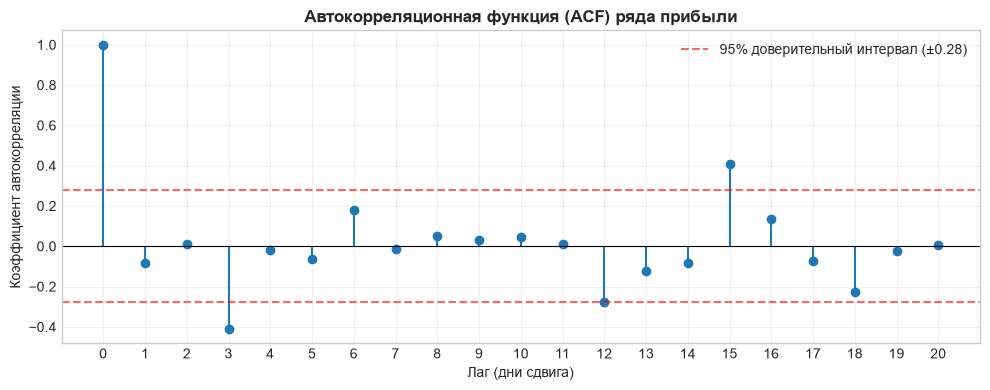

Значения ACF прибыли (первые 16 лагов):
Лаг  0: +1.000
Лаг  1: -0.084
Лаг  2: +0.011
Лаг  3: -0.412
Лаг  4: -0.018
Лаг  5: -0.061
Лаг  6: +0.180
Лаг  7: -0.015
Лаг  8: +0.048
Лаг  9: +0.029
Лаг 10: +0.047
Лаг 11: +0.009
Лаг 12: -0.279
Лаг 13: -0.121
Лаг 14: -0.082
Лаг 15: +0.409


In [5]:
profit_values = np.asarray(df["прибыль"].to_numpy(), dtype=float)

max_lags = 20
acf_profit = compute_autocorrelation(profit_values, max_lags=max_lags)
lags = np.arange(len(acf_profit))

plt.figure(figsize=(10, 4))
plt.stem(lags, acf_profit, basefmt=" ")
# Доверительный интервал 95% для белого шума: +- 1.96 / sqrt(N)
ci = 1.96 / np.sqrt(len(df))
plt.axhline(ci, color='red', linestyle='--', alpha=0.6, label=f'95% доверительный интервал (±{ci:.2f})')
plt.axhline(-ci, color='red', linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Автокорреляционная функция (ACF) ряда прибыли', fontsize=12, fontweight='bold')
plt.xlabel('Лаг (дни сдвига)')
plt.ylabel('Коэффициент автокорреляции')
plt.xticks(lags)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Значения ACF прибыли (первые 16 лагов):")
for lag, val in enumerate(acf_profit[:16]):
    print(f"Лаг {lag:2d}: {val:+.3f}")

**Скрытая периодичность (ACF):**
- На лаге 3 зафиксирован статистически значимый отрицательный выброс ($r_3 = -0.412$), выходящий за пределы 95% доверительного интервала. Это указывает на регулярную смену фаз: за локальным всплеском спроса через 3 дня следует закономерный откат.
- На лаге 15 наблюдается выраженный положительный пик ($r_{15} = +0.409$), также превышающий порог случайности. Это свидетельствует о полумесячном цикле повторных закупок.
- На лаге 1 автокорреляция практически нулевая ($r_1 = -0.084$), что говорит об отсутствии гладкой инерционности между соседними днями.

# 2. Задача 2. Экспериментальное исследование методов фильтрации

Исследуем поведение четырех реализованных алгоритмов фильтрации на временном ряде прибыли.
Для каждого метода выполним:
1. Варьирование ключевых гиперпараметров.
2. Оценку метрик качества (MSE, MAE, степень сглаживания Smoothness Ratio, корреляция с исходным рядом).
3. Визуализацию фазовой задержки и сохранения локальных экстремумов.

## 2.1 Исследование методов

### 2.1.1 Исследование экспоненциального сглаживания (EMA)


Метрики для Экспоненциального сглаживания (EMA):
Alpha = 0.1 | MSE: 2.6238 | Corr: 0.3605 | Smoothness: 0.0051
Alpha = 0.25 | MSE: 1.9779 | Corr: 0.6524 | Smoothness: 0.0357
Alpha = 0.5 | MSE: 1.0306 | Corr: 0.869 | Smoothness: 0.1683


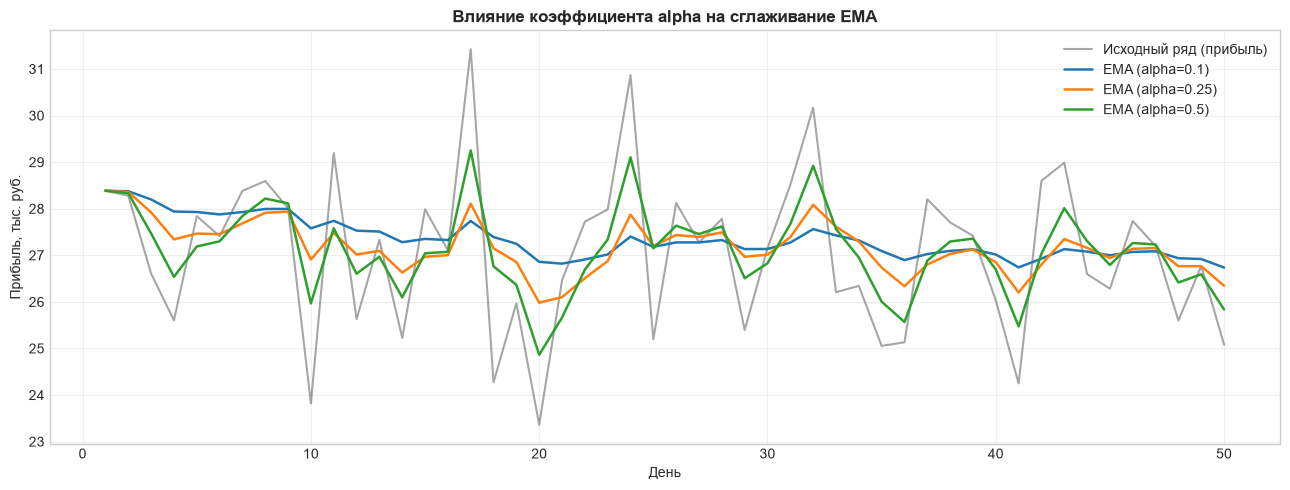

In [6]:
series = np.asarray(df["прибыль"].to_numpy(), dtype=float)
days = np.asarray(df["day"].to_numpy())

alphas = [0.1, 0.25, 0.5]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(days, series, color='black', alpha=0.35, linewidth=1.5, label='Исходный ряд (прибыль)')

print("Метрики для Экспоненциального сглаживания (EMA):")
for a in alphas:
    ema_filter = ExponentialSmoothing(alpha=a)
    smoothed = ema_filter.apply(series)
    metrics = compute_metrics(series, smoothed)
    print(f"Alpha = {a} | MSE: {metrics['MSE']} | Corr: {metrics['Correlation']} | Smoothness: {metrics['Smoothness_Ratio']}")
    ax.plot(days, smoothed, linewidth=1.8, label=f'EMA (alpha={a})')

ax.set_title('Влияние коэффициента alpha на сглаживание EMA', fontsize=12, fontweight='bold')
ax.set_xlabel('День')
ax.set_ylabel('Прибыль, тыс. руб.')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.1.2 Исследование одномерного фильтра Калмана (1D)

Метрики для Фильтра Калмана (1D) при R = 1.0
Q = 0.01 | MSE: 2.5283 | Corr: 0.4233 | Smoothness: 0.0063
Q = 0.05 | MSE: 2.1523 | Corr: 0.5995 | Smoothness: 0.023
Q = 0.2 | MSE: 1.5483 | Corr: 0.772 | Smoothness: 0.0791


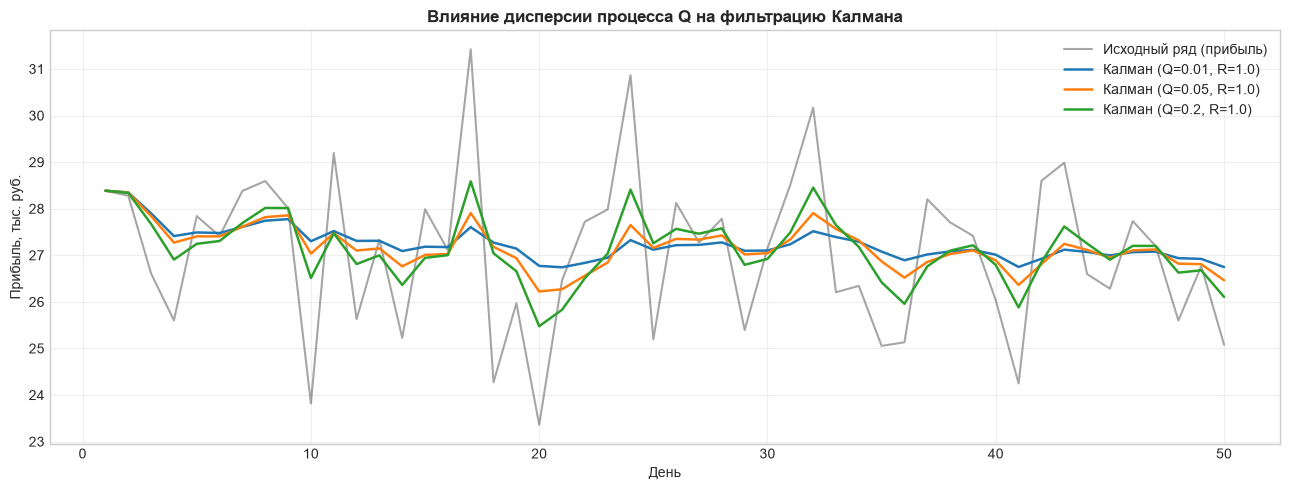

In [7]:
q_values = [0.01, 0.05, 0.2]
r_fixed = 1.0

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(days, series, color='black', alpha=0.35, linewidth=1.5, label='Исходный ряд (прибыль)')

print("Метрики для Фильтра Калмана (1D) при R = 1.0")
for q in q_values:
    kf = KalmanFilter1D(q=q, r=r_fixed)
    filtered = kf.apply(series)
    metrics = compute_metrics(series, filtered)
    print(f"Q = {q} | MSE: {metrics['MSE']} | Corr: {metrics['Correlation']} | Smoothness: {metrics['Smoothness_Ratio']}")
    ax.plot(days, filtered, linewidth=1.8, label=f'Калман (Q={q}, R={r_fixed})')

ax.set_title('Влияние дисперсии процесса Q на фильтрацию Калмана', fontsize=12, fontweight='bold')
ax.set_xlabel('День')
ax.set_ylabel('Прибыль, тыс. руб.')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.1.3 Исследование фильтра Савицкого-Голея


Метрики для Фильтра Савицкого-Голея (Степень полинома d = 2)
Окно w = 5 | MSE: 1.8107 | Corr: 0.615 | Smoothness: 0.2516
Окно w = 7 | MSE: 1.551 | Corr: 0.6915 | Smoothness: 0.1127
Окно w = 11 | MSE: 2.509 | Corr: 0.3552 | Smoothness: 0.0261


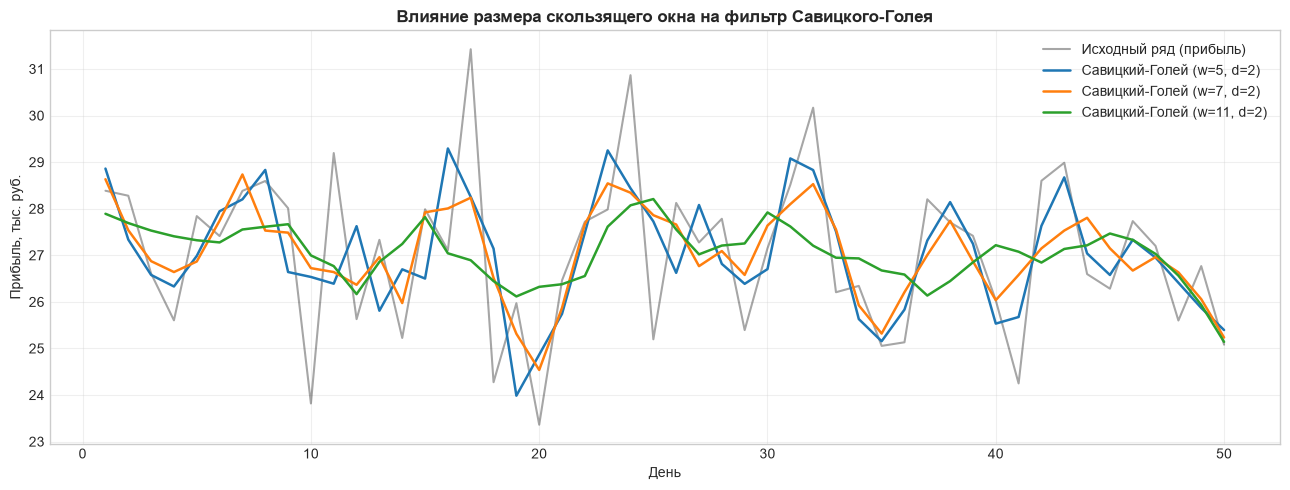

In [8]:
windows = [5, 7, 11]
poly_order = 2

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(days, series, color='black', alpha=0.35, linewidth=1.5, label='Исходный ряд (прибыль)')

print("Метрики для Фильтра Савицкого-Голея (Степень полинома d = 2)")
for w in windows:
    sg = SavitzkyGolayFilter(window_size=w, poly_order=poly_order)
    filtered = sg.apply(series)
    metrics = compute_metrics(series, filtered)
    print(f"Окно w = {w} | MSE: {metrics['MSE']} | Corr: {metrics['Correlation']} | Smoothness: {metrics['Smoothness_Ratio']}")
    ax.plot(days, filtered, linewidth=1.8, label=f'Савицкий-Голей (w={w}, d={poly_order})')

ax.set_title('Влияние размера скользящего окна на фильтр Савицкого-Голея', fontsize=12, fontweight='bold')
ax.set_xlabel('День')
ax.set_ylabel('Прибыль, тыс. руб.')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.1.4 Исследование адаптивного фильтра LMS
 Порядок 4 выбран с опорой на ACF (лаг 3 показал выраженную автокорреляцию)

Метрики для Адаптивного фильтра LMS (Порядок p = 4)
Шаг mu = 0.01 | MSE: 2.7742 | Corr: 0.2407 | Smoothness: 0.0238
Шаг mu = 0.05 | MSE: 2.689 | Corr: 0.3091 | Smoothness: 0.0627
Шаг mu = 0.1 | MSE: 2.7384 | Corr: 0.3119 | Smoothness: 0.1489


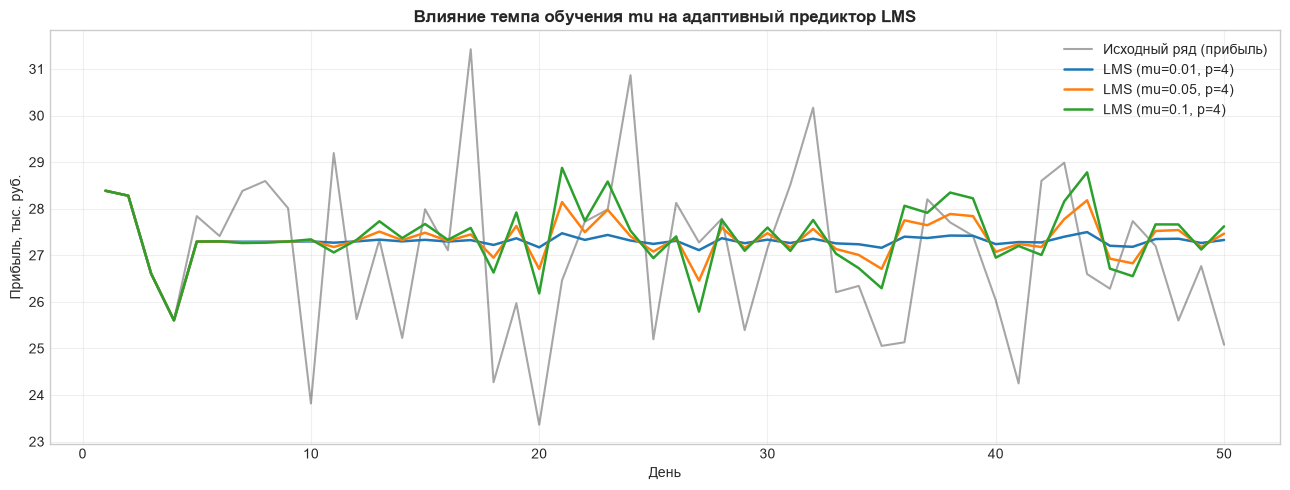

In [9]:

mu_values = [0.01, 0.05, 0.1]
order = 4

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(days, series, color='black', alpha=0.35, linewidth=1.5, label='Исходный ряд (прибыль)')

print(f"Метрики для Адаптивного фильтра LMS (Порядок p = {order})")
for mu in mu_values:
    lms = LMSFilter(order=order, mu=mu)
    filtered = lms.apply(series)
    metrics = compute_metrics(series, filtered)
    print(f"Шаг mu = {mu} | MSE: {metrics['MSE']} | Corr: {metrics['Correlation']} | Smoothness: {metrics['Smoothness_Ratio']}")
    ax.plot(days, filtered, linewidth=1.8, label=f'LMS (mu={mu}, p={order})')

ax.set_title('Влияние темпа обучения mu на адаптивный предиктор LMS', fontsize=12, fontweight='bold')
ax.set_xlabel('День')
ax.set_ylabel('Прибыль, тыс. руб.')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.1.5 Обоснование выбора оптимальных гиперпараметров

На основе компромисса между подавлением случайных флуктуаций (`Smoothness_Ratio`) и сохранением формы сигнала (`Correlation`, `MSE`) зафиксированы следующие конфигурации:

1. **Экспоненциальное сглаживание: $\alpha = 0.25$**
   - При $\alpha = 0.10$ фильтр дает слишком сильный фазовый лаг, корреляция падает до $0.36$.
   - При $\alpha = 0.50$ кривая практически повторяет шум ($Smoothness = 0.1683$).
   - Значение $\alpha = 0.25$ выступает балансом: шум подавлен более чем в 25 раз по сравнению с сырым рядом ($Smoothness = 0.0357$), а корреляция сохраняется на уровне $0.652$.

2. **Фильтр Калмана (1D): $Q = 0.05, R = 1.0$**
   - При $Q = 0.01$ оценка процесса оказывается зажата и не успевает за локальными трендами.
   - При $Q = 0.20$ фильтр избыточно доверяет шумным измерениям.
   - Отношение $Q/R = 0.05$ обеспечивает плавную траекторию с сохранением значимых скачков ($Smoothness = 0.0230$, $r = 0.600$).

3. **Фильтр Савицкого-Голея: $w = 7, d = 2$**
   - Окно $w = 11$ слишком широко для выборки из 50 точек и срезает полезные экстремумы ($r = 0.355$).
   - Окно $w = 5$ пропускает много локальных шумов.
   - Окно $w = 7$ показало наилучшие значения по точности во всей серии тестов: минимальный $MSE = 1.551$ и максимальную корреляцию $r = 0.692$.

4. **Адаптивный фильтр LMS: $\mu = 0.05, p = 4$**
   - Шаг $\mu = 0.01$ дает медленную адаптацию, алгоритм не успевает перестраивать веса под колебания.
   - Шаг $\mu = 0.10$ делает предиктор нестабильным, заставляя его реагировать на шум.
   - При $\mu = 0.05$ достигается минимальная ошибка предсказания ($MSE = 2.689$) при стабильном подавлении шума ($Smoothness = 0.0627$).

## 2.2 Сравнительный анализ работы алгоритмов на оптимальных параметрах
Сравним четыре выбранных метода на общем графике и исследуем свойства выделенного шума (остатков фильтрации). Для качественного фильтра остатки должны напоминать некоррелированный белый шум около нуля, не содержащий в себе невыявленного тренда.

### 2.2.1 Построение сводного графика сглаживания


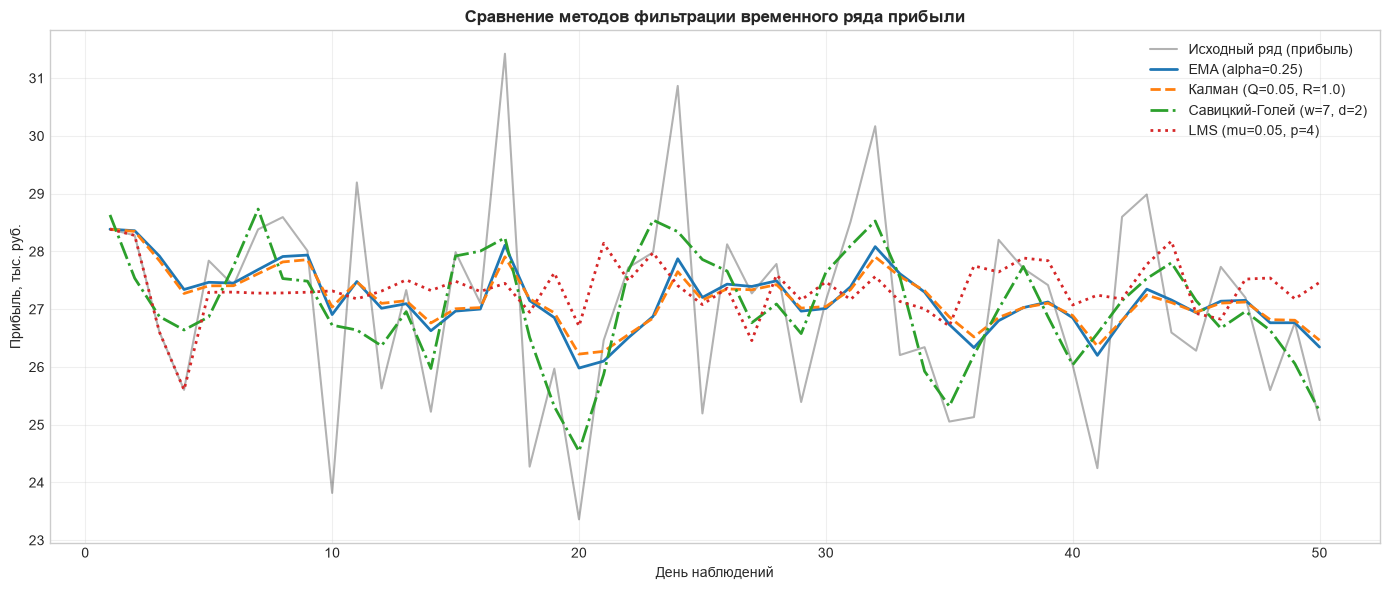

In [10]:
best_filters = {
    'EMA (alpha=0.25)': ExponentialSmoothing(alpha=0.25),
    'Калман (Q=0.05, R=1.0)': KalmanFilter1D(q=0.05, r=1.0),
    'Савицкий-Голей (w=7, d=2)': SavitzkyGolayFilter(window_size=7, poly_order=2),
    'LMS (mu=0.05, p=4)': LMSFilter(mu=0.05, order=4)
}

filtered_data = {name: flt.apply(series) for name, flt in best_filters.items()}

plt.figure(figsize=(14, 6))
plt.plot(days, series, color='black', alpha=0.3, linewidth=1.5, label='Исходный ряд (прибыль)')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
styles = ['-', '--', '-.', ':']

for (name, smoothed), c, s in zip(filtered_data.items(), colors, styles):
    plt.plot(days, smoothed, label=name, color=c, linestyle=s, linewidth=2.0)

plt.title('Сравнение методов фильтрации временного ряда прибыли', fontsize=12, fontweight='bold')
plt.xlabel('День наблюдений')
plt.ylabel('Прибыль, тыс. руб.')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2.2. Анализ остатков фильтрации $e_t = x_t - x_filtered$


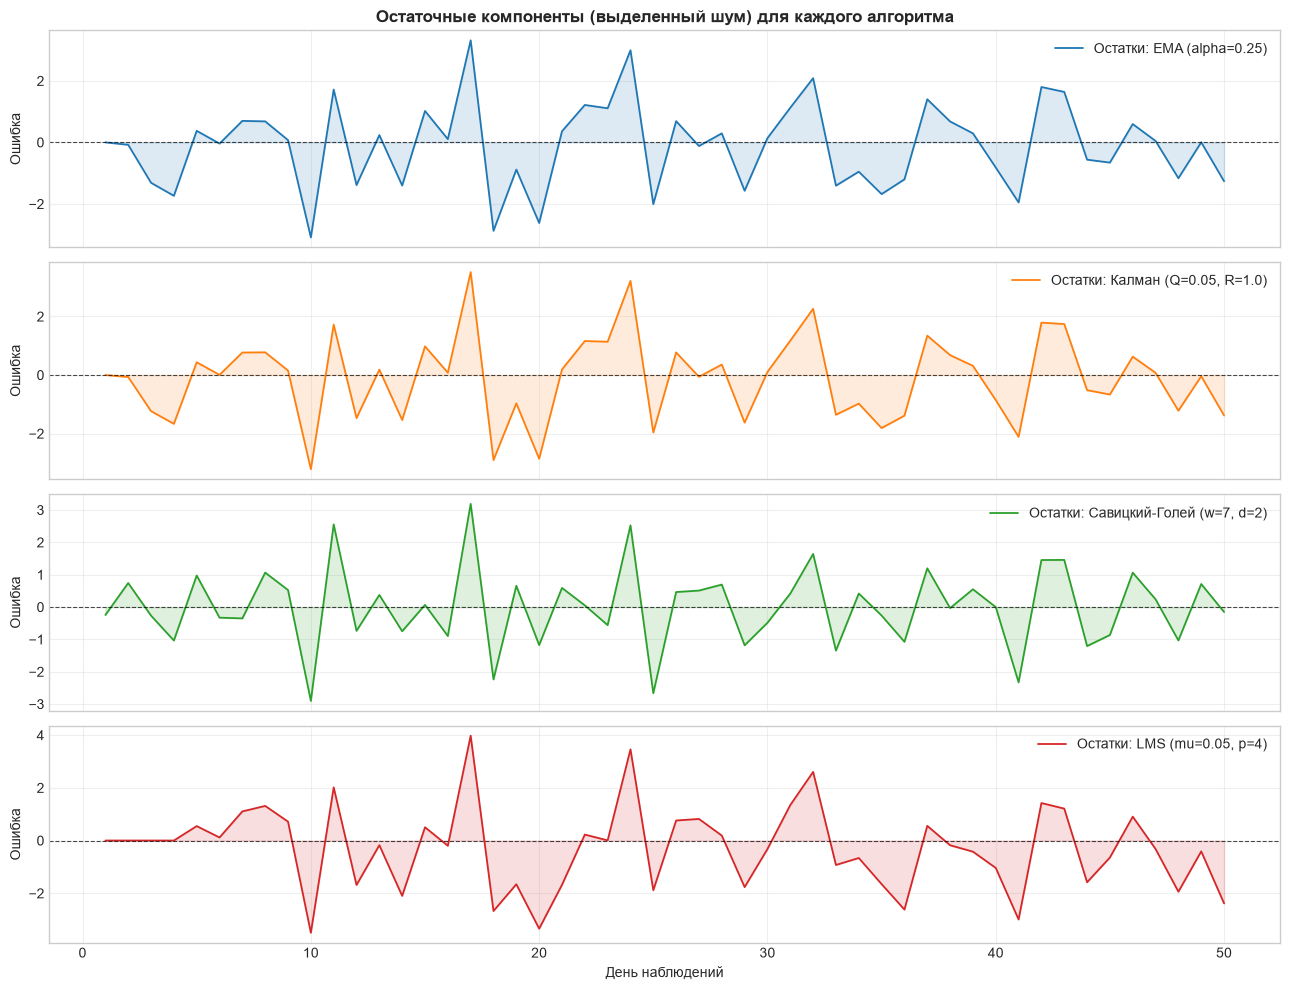

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for ax, (name, smoothed), c in zip(axes, filtered_data.items(), colors):
    residual = series - smoothed
    ax.plot(days, residual, color=c, linewidth=1.3, label=f'Остатки: {name}')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.fill_between(days, residual, 0, color=c, alpha=0.15)
    ax.set_ylabel('Ошибка')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('День наблюдений')
axes[0].set_title('Остаточные компоненты (выделенный шум) для каждого алгоритма', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 Количественная оценка качества

### 2.3.1 Расчет сводной таблицы характеристик фильтров


In [14]:
records: list[dict[str, Any]] = []

for name, smoothed in filtered_data.items():
    m = compute_metrics(series, smoothed)
    m['Алгоритм'] = name # type: ignore
    records.append(m)

df_summary = pd.DataFrame(records)[['Алгоритм', 'MSE', 'MAE', 'Smoothness_Ratio', 'Correlation']]

print("Сводная таблица метрик качества фильтрации:")
display(df_summary)

Сводная таблица метрик качества фильтрации:


,Алгоритм,MSE,MAE,Smoothness_Ratio,Correlation
0,EMA (alpha=0.25),1.9779,1.1096,0.0357,0.6524
1,"Калман (Q=0.05, R=1.0)",2.1523,1.1499,0.0230,0.5995
2,"Савицкий-Голей (w=7, d=2)",1.5510,0.9651,0.1127,0.6915
3,"LMS (mu=0.05, p=4)",2.6890,1.2515,0.0627,0.3091


## 2.4 Сравнительный анализ эффективности фильтрации (Задача 2)

На основе количественных метрик и визуального анализа выделенного шума можно сделать следующие выводы:

1. **Фильтр Савицкого-Голея ($w=7, d=2$) показал наилучшую точность аппроксимации:**
   - Алгоритм достиг минимальных значений ошибок ($MSE = 1.5510$, $MAE = 0.9651$) и максимальной корреляции с исходным рядом ($r = 0.6915$)
   - На графике видно, что локальная полиномиальная регрессия сохраняет крутизну склонов и форму локальных пиков (дни 17, 24, 32), не срезая их так грубо, как рекуррентные методы
   - График остатков для Савицкого-Голея наиболее симметричен относительно нуля и не содержит фазового сдвига, что подтверждает корректное выделение именно высокочастотного шума

2. **Фильтр Калмана (1D) обеспечил максимальное подавление шума:**
   - Метод продемонстрировал наименьший показатель `Smoothness_Ratio = 0.0230`. Это означает, что дисперсия дневных скачков ряда снизилась более чем в 43 раза
   - Платой за такую стабильность является фазовое запаздывание: фильтр сглаживает резкие пики прибыли, подтягивая их ближе к текущей оценке математического ожидания
   - Рекуррентное экспоненциальное сглаживание (EMA) при $\alpha = 0.25$ ведет себя практически идентично Калману ($Smoothness = 0.0357$, $r = 0.6524$), подтверждая теоретическое родство скалярной байесовской фильтрации и фильтров первого порядка

3. **Специфика адаптивного фильтра LMS:**
   - LMS работал в режиме адаптивного линейного предиктора 4-го порядка
   - Поскольку случайный шум во временном ряде некоррелирован, предсказание следующего дня по предыдущим неизбежно дает запаздывание на один шаг, из-за чего $MSE = 2.6890$, а корреляция составила $0.3091$
   - Тем не менее, градиентный спуск успешно подавил случайный разброс ($Smoothness = 0.0627$), удерживая траекторию вокруг стабильного среднего уровня без ухода в расходимость

# 3. Задача 4. Хард свобода: фильтрация данных двойных инерциальных датчиков

Будут исследоваться реальные сигналы двухосевого акселерометра смартфона (оси X и Y), которые я записал при перемещении устройства.

Цели:
1. Выделить полезную кинематическую составляющую движения из зашумленного высокочастотного сигнала (частота опроса ~200 Гц)
2. Сравнить работу фильтра Калмана и фильтра Савицкого-Голея на физических сенсорных данных
3. Построить фазовую траекторию на плоскости $(a_x, a_y)$ до и после фильтрации

# 3.1. Загрузка данных акселерометра

In [ ]:
df_sensors = pd.read_csv('sensors.csv')

time_s = df_sensors['Time (s)'].values
raw_ax = df_sensors['Linear Acceleration x (m/s^2)'].values
raw_ay = df_sensors['Linear Acceleration y (m/s^2)'].values

print("Количество отсчетов:", len(df_sensors))
start_time = float(time_s[0])
end_time = float(time_s[-1])
duration = end_time - start_time

print(
    f"Интервал записи: от {start_time:.3f} с до "
    f"{end_time:.3f} с (частота ~{len(time_s) / duration:.0f} Гц)"
)
display(df_sensors[['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)']].describe().round(3))

Количество отсчетов: 4113
Интервал записи: от 0.006 с до 20.566 с (частота ~200 Гц)


,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2)
count,4113.000,4113.000,4113.000
mean,10.286,0.017,-0.920
std,5.937,3.401,2.331
min,0.006,-39.462,-33.172
25%,5.146,-1.419,-1.646
50%,10.286,-0.035,-0.149
75%,15.426,1.151,0.107
max,20.566,25.576,11.993
